In [4]:
#import math
#import numpy as np
#import dateutil as du
import pandas as pd
#import datetime
%matplotlib inline
import matplotlib.pyplot as plt
#import matplotlib.patches as patches
#from metpy.plots import StationPlot #, sky_cover, current_weather
#from metpy.units import units

import modules.URLhandler as URLhandler
import modules.feelsLikeCalc as fLCalc
import modules.timeHandler as timeHandler

In [5]:
# Rounding is performed because the API can't handle precision higher than 4 places.
#lat = round(float(input("Enter the latitude of the city (e.g. Ames: 42.00, KOWA: 44.12):")), 4)
#lon = round(float(input("Enter the longitude of the city (e.g. Ames: -93.62, KOWA: -93.26):")), 4)

# Lynchburg, VA [KLYH]:
lat = 37.3208
lon = -79.2067

# Ames:
#lat = 42.0347
#lon = -93.6199

In [6]:
# Base of the URL used for the OpenMeteo API.
api_URL_base = "https://api.open-meteo.com/v1/forecast"

# Names of the variables requested from the API.
variableNames = "&hourly=temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover,wind_speed_10m,wind_direction_10m"

# Names of the units the variables should be in.
variableUnits = "&temperature_unit=fahrenheit&wind_speed_unit=mph&precipitation_unit=inch"

# Enter in the number of forecast days. Must be an integer between 1 and 16.
forecastDays = str(int(10))

In [7]:
api_URL_NOAA = api_URL_base + "?latitude=" + str(lat) + "&longitude=" + str(lon) + variableNames + variableUnits + "&forecast_days=" + forecastDays + "&models=gfs_global,gfs_hrrr,ncep_nbm_conus,gfs_graphcast025"

dataNOAA = URLhandler.URLcollectorJSON(api_URL_NOAA, "NOAA forecast data")

In [8]:
print(api_URL_NOAA)

https://api.open-meteo.com/v1/forecast?latitude=37.3208&longitude=-79.2067&hourly=temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,cloud_cover,wind_speed_10m,wind_direction_10m&temperature_unit=fahrenheit&wind_speed_unit=mph&precipitation_unit=inch&forecast_days=10&models=gfs_global,gfs_hrrr,ncep_nbm_conus,gfs_graphcast025


In [9]:
api_URL_ECMWF = api_URL_base + "?latitude=" + str(lat) + "&longitude=" + str(lon) + variableNames + variableUnits + "&forecast_days=" + forecastDays + "&models=ecmwf_ifs025,ecmwf_aifs025"

dataECMWF = URLhandler.URLcollectorJSON(api_URL_ECMWF, "ECMWF forecast data")

In [10]:
api_URL_GEM = api_URL_base + "?latitude=" + str(lat) + "&longitude=" + str(lon) + variableNames + variableUnits + "&forecast_days=" + forecastDays + "&models=gem_global,gem_regional,gem_hrdps_continental"

dataGEM = URLhandler.URLcollectorJSON(api_URL_GEM, "GEM forecast data")

In [11]:
print(dataNOAA['hourly'].keys())

dict_keys(['time', 'temperature_2m_gfs_global', 'relative_humidity_2m_gfs_global', 'dew_point_2m_gfs_global', 'apparent_temperature_gfs_global', 'cloud_cover_gfs_global', 'wind_speed_10m_gfs_global', 'wind_direction_10m_gfs_global', 'temperature_2m_gfs_hrrr', 'relative_humidity_2m_gfs_hrrr', 'dew_point_2m_gfs_hrrr', 'apparent_temperature_gfs_hrrr', 'cloud_cover_gfs_hrrr', 'wind_speed_10m_gfs_hrrr', 'wind_direction_10m_gfs_hrrr', 'temperature_2m_ncep_nbm_conus', 'relative_humidity_2m_ncep_nbm_conus', 'dew_point_2m_ncep_nbm_conus', 'apparent_temperature_ncep_nbm_conus', 'cloud_cover_ncep_nbm_conus', 'wind_speed_10m_ncep_nbm_conus', 'wind_direction_10m_ncep_nbm_conus', 'temperature_2m_gfs_graphcast025', 'relative_humidity_2m_gfs_graphcast025', 'dew_point_2m_gfs_graphcast025', 'apparent_temperature_gfs_graphcast025', 'cloud_cover_gfs_graphcast025', 'wind_speed_10m_gfs_graphcast025', 'wind_direction_10m_gfs_graphcast025'])


In [12]:
NOAAdataLength = len(dataNOAA['hourly']['time'])

In [13]:
# Naming here makes it much easier to handle in the event I want to change the names.
timeName = "timestamp"
temperatureName = "temperature"
dewpointName = "dewpoint"
rhName = "relativeHumidity"
feelsLikeName = "apparentTemp"
cloudCoverName = "cloudCover"
CAPEname= "convectiveEnergy"
popName = "probabilityOfPrecip"
windDirName = "windDirection"
windSpeedName = "windSpeed"
nightName = "nighttimes"
precipTypesName = "precipType"

In [14]:
# Common dictionary format for all forecasts.
dictForecast = {timeName:        [None]*NOAAdataLength,
                temperatureName: [None]*NOAAdataLength,
                dewpointName:    [None]*NOAAdataLength,
                rhName:          [None]*NOAAdataLength,
                feelsLikeName:   [None]*NOAAdataLength,
                cloudCoverName:  [None]*NOAAdataLength,
                windDirName:     [None]*NOAAdataLength,
                windSpeedName:   [None]*NOAAdataLength}

GFSdataframe = pd.DataFrame(dictForecast)
GFS_GCdataframe = pd.DataFrame(dictForecast)
HRRRdataframe = pd.DataFrame(dictForecast)
NBMdataframe = pd.DataFrame(dictForecast)

ECMWFdataframe = pd.DataFrame(dictForecast)
ECMWF_AIdataframe = pd.DataFrame(dictForecast)

GDPSdataframe = pd.DataFrame(dictForecast)
RDPSdataframe = pd.DataFrame(dictForecast)
HRDPSdataframe = pd.DataFrame(dictForecast)

In [15]:
if('temperature_2m_gfs_global' in dataNOAA['hourly']):
    GFSdataframe[timeName]        = dataNOAA['hourly']['time']
    GFSdataframe[temperatureName] = dataNOAA['hourly']['temperature_2m_gfs_global']
    GFSdataframe[dewpointName]    = dataNOAA['hourly']['dew_point_2m_gfs_global']
    GFSdataframe[rhName]          = dataNOAA['hourly']['relative_humidity_2m_gfs_global']
    GFSdataframe[feelsLikeName]   = dataNOAA['hourly']['apparent_temperature_gfs_global']
    GFSdataframe[cloudCoverName]  = dataNOAA['hourly']['cloud_cover_gfs_global']
    GFSdataframe[windDirName]     = dataNOAA['hourly']['wind_direction_10m_gfs_global']
    GFSdataframe[windSpeedName]   = dataNOAA['hourly']['wind_speed_10m_gfs_global']

In [16]:
if('temperature_2m_gfs_graphcast025' in dataNOAA['hourly']):
    GFS_GCdataframe[timeName]        = dataNOAA['hourly']['time']
    GFS_GCdataframe[temperatureName] = dataNOAA['hourly']['temperature_2m_gfs_graphcast025']
    GFS_GCdataframe[dewpointName]    = dataNOAA['hourly']['dew_point_2m_gfs_graphcast025']
    GFS_GCdataframe[rhName]          = dataNOAA['hourly']['relative_humidity_2m_gfs_graphcast025']
    GFS_GCdataframe[feelsLikeName]   = dataNOAA['hourly']['apparent_temperature_gfs_graphcast025']
    GFS_GCdataframe[cloudCoverName]  = dataNOAA['hourly']['cloud_cover_gfs_graphcast025']
    GFS_GCdataframe[windDirName]     = dataNOAA['hourly']['wind_direction_10m_gfs_graphcast025']
    GFS_GCdataframe[windSpeedName]   = dataNOAA['hourly']['wind_speed_10m_gfs_graphcast025']

In [17]:
if('temperature_2m_gfs_hrrr' in dataNOAA['hourly']):
    HRRRdataframe[timeName]        = dataNOAA['hourly']['time']
    HRRRdataframe[temperatureName] = dataNOAA['hourly']['temperature_2m_gfs_hrrr']
    HRRRdataframe[dewpointName]    = dataNOAA['hourly']['dew_point_2m_gfs_hrrr']
    HRRRdataframe[rhName]          = dataNOAA['hourly']['relative_humidity_2m_gfs_hrrr']
    HRRRdataframe[feelsLikeName]   = dataNOAA['hourly']['apparent_temperature_gfs_hrrr']
    HRRRdataframe[cloudCoverName]  = dataNOAA['hourly']['cloud_cover_gfs_hrrr']
    HRRRdataframe[windDirName]     = dataNOAA['hourly']['wind_direction_10m_gfs_hrrr']
    HRRRdataframe[windSpeedName]   = dataNOAA['hourly']['wind_speed_10m_gfs_hrrr']

In [18]:
if('temperature_2m_ncep_nbm_conus' in dataNOAA['hourly']):
    NBMdataframe[timeName]        = dataNOAA['hourly']['time']
    NBMdataframe[temperatureName] = dataNOAA['hourly']['temperature_2m_ncep_nbm_conus']
    NBMdataframe[dewpointName]    = dataNOAA['hourly']['dew_point_2m_ncep_nbm_conus']
    NBMdataframe[rhName]          = dataNOAA['hourly']['relative_humidity_2m_ncep_nbm_conus']
    NBMdataframe[feelsLikeName]   = dataNOAA['hourly']['apparent_temperature_ncep_nbm_conus']
    NBMdataframe[cloudCoverName]  = dataNOAA['hourly']['cloud_cover_ncep_nbm_conus']
    NBMdataframe[windDirName]     = dataNOAA['hourly']['wind_direction_10m_ncep_nbm_conus']
    NBMdataframe[windSpeedName]   = dataNOAA['hourly']['wind_speed_10m_ncep_nbm_conus']

In [19]:
if('temperature_2m_ecmwf_ifs025' in dataECMWF['hourly']):
    ECMWFdataframe[timeName]        = dataECMWF['hourly']['time']
    ECMWFdataframe[temperatureName] = dataECMWF['hourly']['temperature_2m_ecmwf_ifs025']
    ECMWFdataframe[dewpointName]    = dataECMWF['hourly']['dew_point_2m_ecmwf_ifs025']
    ECMWFdataframe[rhName]          = dataECMWF['hourly']['relative_humidity_2m_ecmwf_ifs025']
    ECMWFdataframe[feelsLikeName]   = dataECMWF['hourly']['apparent_temperature_ecmwf_ifs025']
    ECMWFdataframe[cloudCoverName]  = dataECMWF['hourly']['cloud_cover_ecmwf_ifs025']
    ECMWFdataframe[windDirName]     = dataECMWF['hourly']['wind_direction_10m_ecmwf_ifs025']
    ECMWFdataframe[windSpeedName]   = dataECMWF['hourly']['wind_speed_10m_ecmwf_ifs025']

In [20]:
if('temperature_2m_ecmwf_aifs025' in dataECMWF['hourly']):
    ECMWF_AIdataframe[timeName]        = dataECMWF['hourly']['time']
    ECMWF_AIdataframe[temperatureName] = dataECMWF['hourly']['temperature_2m_ecmwf_aifs025']
    ECMWF_AIdataframe[dewpointName]    = dataECMWF['hourly']['dew_point_2m_ecmwf_aifs025']
    ECMWF_AIdataframe[rhName]          = dataECMWF['hourly']['relative_humidity_2m_ecmwf_aifs025']
    ECMWF_AIdataframe[feelsLikeName]   = dataECMWF['hourly']['apparent_temperature_ecmwf_aifs025']
    ECMWF_AIdataframe[cloudCoverName]  = dataECMWF['hourly']['cloud_cover_ecmwf_aifs025']
    ECMWF_AIdataframe[windDirName]     = dataECMWF['hourly']['wind_direction_10m_ecmwf_aifs025']
    ECMWF_AIdataframe[windSpeedName]   = dataECMWF['hourly']['wind_speed_10m_ecmwf_aifs025']

In [21]:
if('temperature_2m_gem_global' in dataGEM['hourly']):
    GDPSdataframe[timeName]        = dataGEM['hourly']['time']
    GDPSdataframe[temperatureName] = dataGEM['hourly']['temperature_2m_gem_global']
    GDPSdataframe[dewpointName]    = dataGEM['hourly']['dew_point_2m_gem_global']
    GDPSdataframe[rhName]          = dataGEM['hourly']['relative_humidity_2m_gem_global']
    GDPSdataframe[feelsLikeName]   = dataGEM['hourly']['apparent_temperature_gem_global']
    GDPSdataframe[cloudCoverName]  = dataGEM['hourly']['cloud_cover_gem_global']
    GDPSdataframe[windDirName]     = dataGEM['hourly']['wind_direction_10m_gem_global']
    GDPSdataframe[windSpeedName]   = dataGEM['hourly']['wind_speed_10m_gem_global']

In [22]:
if('temperature_2m_gem_regional' in dataGEM['hourly']):
    RDPSdataframe[timeName]        = dataGEM['hourly']['time']
    RDPSdataframe[temperatureName] = dataGEM['hourly']['temperature_2m_gem_regional']
    RDPSdataframe[dewpointName]    = dataGEM['hourly']['dew_point_2m_gem_regional']
    RDPSdataframe[rhName]          = dataGEM['hourly']['relative_humidity_2m_gem_regional']
    RDPSdataframe[feelsLikeName]   = dataGEM['hourly']['apparent_temperature_gem_regional']
    RDPSdataframe[cloudCoverName]  = dataGEM['hourly']['cloud_cover_gem_regional']
    RDPSdataframe[windDirName]     = dataGEM['hourly']['wind_direction_10m_gem_regional']
    RDPSdataframe[windSpeedName]   = dataGEM['hourly']['wind_speed_10m_gem_regional']

In [23]:
if('temperature_2m_gem_hrdps_continental' in dataGEM['hourly']):
    HRDPSdataframe[timeName]        = dataGEM['hourly']['time']
    HRDPSdataframe[temperatureName] = dataGEM['hourly']['temperature_2m_gem_hrdps_continental']
    HRDPSdataframe[dewpointName]    = dataGEM['hourly']['dew_point_2m_gem_hrdps_continental']
    HRDPSdataframe[rhName]          = dataGEM['hourly']['relative_humidity_2m_gem_hrdps_continental']
    HRDPSdataframe[feelsLikeName]   = dataGEM['hourly']['apparent_temperature_gem_hrdps_continental']
    HRDPSdataframe[cloudCoverName]  = dataGEM['hourly']['cloud_cover_gem_hrdps_continental']
    HRDPSdataframe[windDirName]     = dataGEM['hourly']['wind_direction_10m_gem_hrdps_continental']
    HRDPSdataframe[windSpeedName]   = dataGEM['hourly']['wind_speed_10m_gem_hrdps_continental']

In [24]:
# Converts the timestamps into a usable format.
if('temperature_2m_gfs_global' in dataNOAA['hourly']):
    GFSdataframe[timeName] = timeHandler.timeParser(GFSdataframe[timeName])
if('temperature_2m_gfs_graphcast025' in dataNOAA['hourly']):
    GFS_GCdataframe[timeName] = timeHandler.timeParser(GFS_GCdataframe[timeName])
if('temperature_2m_gfs_hrrr' in dataNOAA['hourly']):
    HRRRdataframe[timeName] = timeHandler.timeParser(HRRRdataframe[timeName])
if('temperature_2m_ncep_nbm_conus' in dataNOAA['hourly']):
    NBMdataframe[timeName] = timeHandler.timeParser(NBMdataframe[timeName])

if('temperature_2m_ecmwf_ifs025' in dataECMWF['hourly']):
    ECMWFdataframe[timeName] = timeHandler.timeParser(ECMWFdataframe[timeName])
if('temperature_2m_ecmwf_aifs025' in dataECMWF['hourly']):
    ECMWF_AIdataframe[timeName] = timeHandler.timeParser(ECMWF_AIdataframe[timeName])

if('temperature_2m_gem_global' in dataGEM['hourly']):
    GDPSdataframe[timeName] = timeHandler.timeParser(GDPSdataframe[timeName])
if('temperature_2m_gem_regional' in dataGEM['hourly']):
    RDPSdataframe[timeName] = timeHandler.timeParser(RDPSdataframe[timeName])
if('temperature_2m_gem_hrdps_continental' in dataGEM['hourly']):
    HRDPSdataframe[timeName] = timeHandler.timeParser(HRDPSdataframe[timeName])

In [25]:
# Set colors for the plots.
GFScolor = "royalblue"
GFS_GCcolor = "lightskyblue"
HRRRcolor = "forestgreen"
NBMcolor = "red"

ECMWFcolor = "xkcd:golden yellow"
ECMWF_AIcolor = "xkcd:pumpkin"

GDPScolor = "xkcd:hot purple"
RDPScolor = "xkcd:electric purple"
HRDPScolor = "xkcd:faded purple"

linewidth = 0.80
NBMlinewidth = 1.25

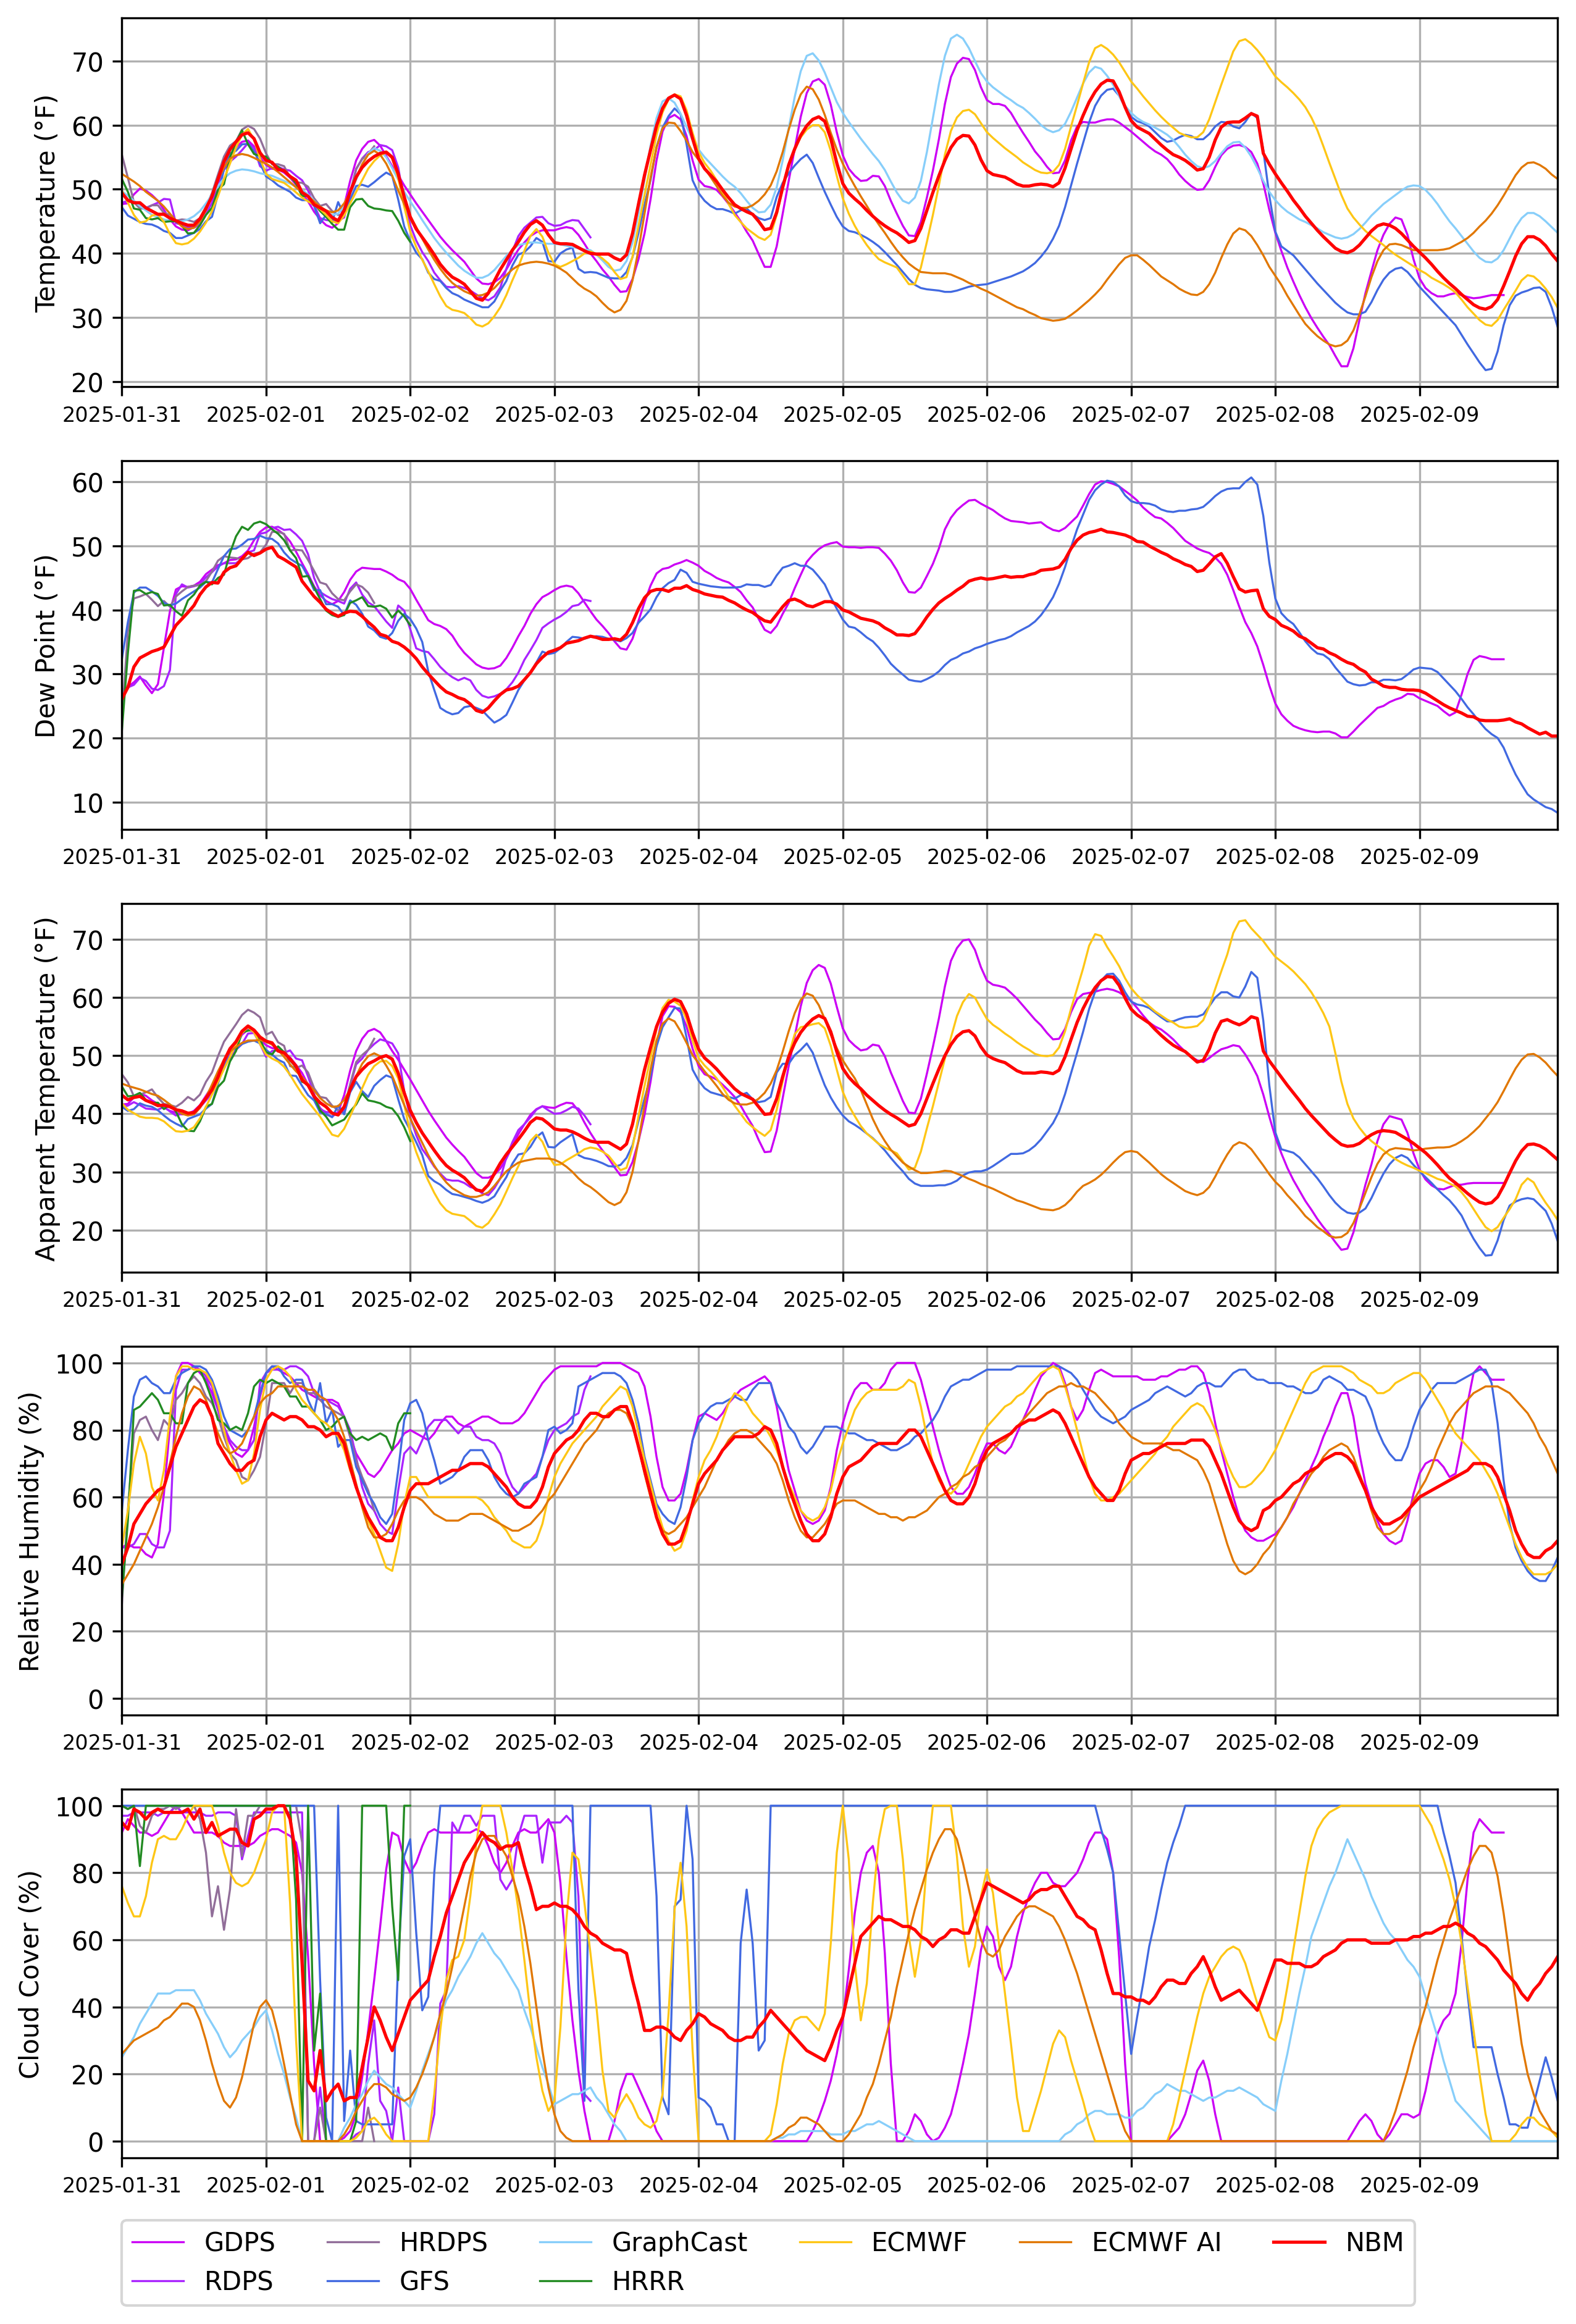

In [26]:
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.labelsize"] = 8
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, figsize=(10,15))

# Plots 2-meter air temperatures.
ax1.plot(GDPSdataframe[timeName], GDPSdataframe[temperatureName], color=GDPScolor, linewidth=linewidth)
ax1.plot(RDPSdataframe[timeName], RDPSdataframe[temperatureName], color=RDPScolor, linewidth=linewidth)
ax1.plot(HRDPSdataframe[timeName], HRDPSdataframe[temperatureName], color=HRDPScolor, linewidth=linewidth)
ax1.plot(GFSdataframe[timeName], GFSdataframe[temperatureName], color=GFScolor, linewidth=linewidth)
ax1.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[temperatureName], color=GFS_GCcolor, linewidth=linewidth)
ax1.plot(HRRRdataframe[timeName], HRRRdataframe[temperatureName], color=HRRRcolor, linewidth=linewidth)
ax1.plot(ECMWFdataframe[timeName], ECMWFdataframe[temperatureName], color=ECMWFcolor, linewidth=linewidth)
ax1.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[temperatureName], color=ECMWF_AIcolor, linewidth=linewidth)
ax1.plot(NBMdataframe[timeName], NBMdataframe[temperatureName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots 2-meter dew point temperatures.
# Some models (GFS-GC, and ECMWF-IFS & -AIFS) lack dew point information.
ax2.plot(GDPSdataframe[timeName], GDPSdataframe[dewpointName], color=GDPScolor, linewidth=linewidth)
ax2.plot(RDPSdataframe[timeName], RDPSdataframe[dewpointName], color=RDPScolor, linewidth=linewidth)
ax2.plot(HRDPSdataframe[timeName], HRDPSdataframe[dewpointName], color=HRDPScolor, linewidth=linewidth)
ax2.plot(GFSdataframe[timeName], GFSdataframe[dewpointName], color=GFScolor, linewidth=linewidth)
ax2.plot(HRRRdataframe[timeName],HRRRdataframe[dewpointName], color=HRRRcolor, linewidth=linewidth)
ax2.plot(NBMdataframe[timeName], NBMdataframe[dewpointName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots 2-meter apparent ("feels like") temperatures.
# Some models (GFS-GC) lack apparent temperature information.
ax3.plot(GDPSdataframe[timeName], GDPSdataframe[feelsLikeName], color=GDPScolor, linewidth=linewidth)
ax3.plot(RDPSdataframe[timeName], RDPSdataframe[feelsLikeName], color=RDPScolor, linewidth=linewidth)
ax3.plot(HRDPSdataframe[timeName], HRDPSdataframe[feelsLikeName], color=HRDPScolor, linewidth=linewidth)
ax3.plot(GFSdataframe[timeName], GFSdataframe[feelsLikeName], color=GFScolor, linewidth=linewidth)
ax3.plot(HRRRdataframe[timeName], HRRRdataframe[feelsLikeName], color=HRRRcolor, linewidth=linewidth)
ax3.plot(ECMWFdataframe[timeName], ECMWFdataframe[feelsLikeName], color=ECMWFcolor, linewidth=linewidth)
ax3.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[feelsLikeName], color=ECMWF_AIcolor, linewidth=linewidth)
ax3.plot(NBMdataframe[timeName], NBMdataframe[feelsLikeName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots 2-meter relative humidities.
# Some models (GFS-GC, and ECMWF-IFS & -AIFS) lack relative humidity information.
ax4.plot(GDPSdataframe[timeName], GDPSdataframe[rhName], color=GDPScolor, linewidth=linewidth)
ax4.plot(RDPSdataframe[timeName], RDPSdataframe[rhName], color=RDPScolor, linewidth=linewidth)
ax4.plot(HRDPSdataframe[timeName], HRDPSdataframe[rhName], color=HRDPScolor, linewidth=linewidth)
ax4.plot(GFSdataframe[timeName], GFSdataframe[rhName], color=GFScolor, linewidth=linewidth)
ax4.plot(HRRRdataframe[timeName], HRRRdataframe[rhName], color=HRRRcolor, linewidth=linewidth)
ax4.plot(ECMWFdataframe[timeName], ECMWFdataframe[rhName], color=ECMWFcolor, linewidth=linewidth)
ax4.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[rhName], color=ECMWF_AIcolor, linewidth=linewidth)
ax4.plot(NBMdataframe[timeName], NBMdataframe[rhName], color=NBMcolor, linewidth=NBMlinewidth)

# Plots total cloud cover data.
ax5.plot(GDPSdataframe[timeName], GDPSdataframe[cloudCoverName], color=GDPScolor, linewidth=linewidth, label="GDPS")
ax5.plot(RDPSdataframe[timeName], RDPSdataframe[cloudCoverName], color=RDPScolor, linewidth=linewidth, label="RDPS")
ax5.plot(HRDPSdataframe[timeName], HRDPSdataframe[cloudCoverName], color=HRDPScolor, linewidth=linewidth, label="HRDPS")
ax5.plot(GFSdataframe[timeName], GFSdataframe[cloudCoverName], color=GFScolor, linewidth=linewidth, label="GFS")
ax5.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[cloudCoverName], color=GFS_GCcolor, linewidth=linewidth, label="GraphCast")
ax5.plot(HRRRdataframe[timeName], HRRRdataframe[cloudCoverName], color=HRRRcolor, linewidth=linewidth, label="HRRR")
ax5.plot(ECMWFdataframe[timeName], ECMWFdataframe[cloudCoverName], color=ECMWFcolor, linewidth=linewidth, label="ECMWF")
ax5.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[cloudCoverName], color=ECMWF_AIcolor, linewidth=linewidth, label="ECMWF AI")
ax5.plot(NBMdataframe[timeName], NBMdataframe[cloudCoverName], color=NBMcolor, linewidth=NBMlinewidth, label="NBM")

# Enables gridding.
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)
ax5.grid(True)

# Sets y-labels and title.
ax1.set_ylabel("Temperature (°F)")
ax2.set_ylabel("Dew Point (°F)")
ax3.set_ylabel("Apparent Temperature (°F)")
ax4.set_ylabel("Relative Humidity (%)")
ax5.set_ylabel("Cloud Cover (%)")

# Adjust the bounds of the plot to make it consistent.
plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax3, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax4, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[-5, 105])
plt.setp(ax5, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[-5, 105])

# Sets the legend and size of it.
leg = ax5.legend(loc=(0, -0.4), ncol=6)

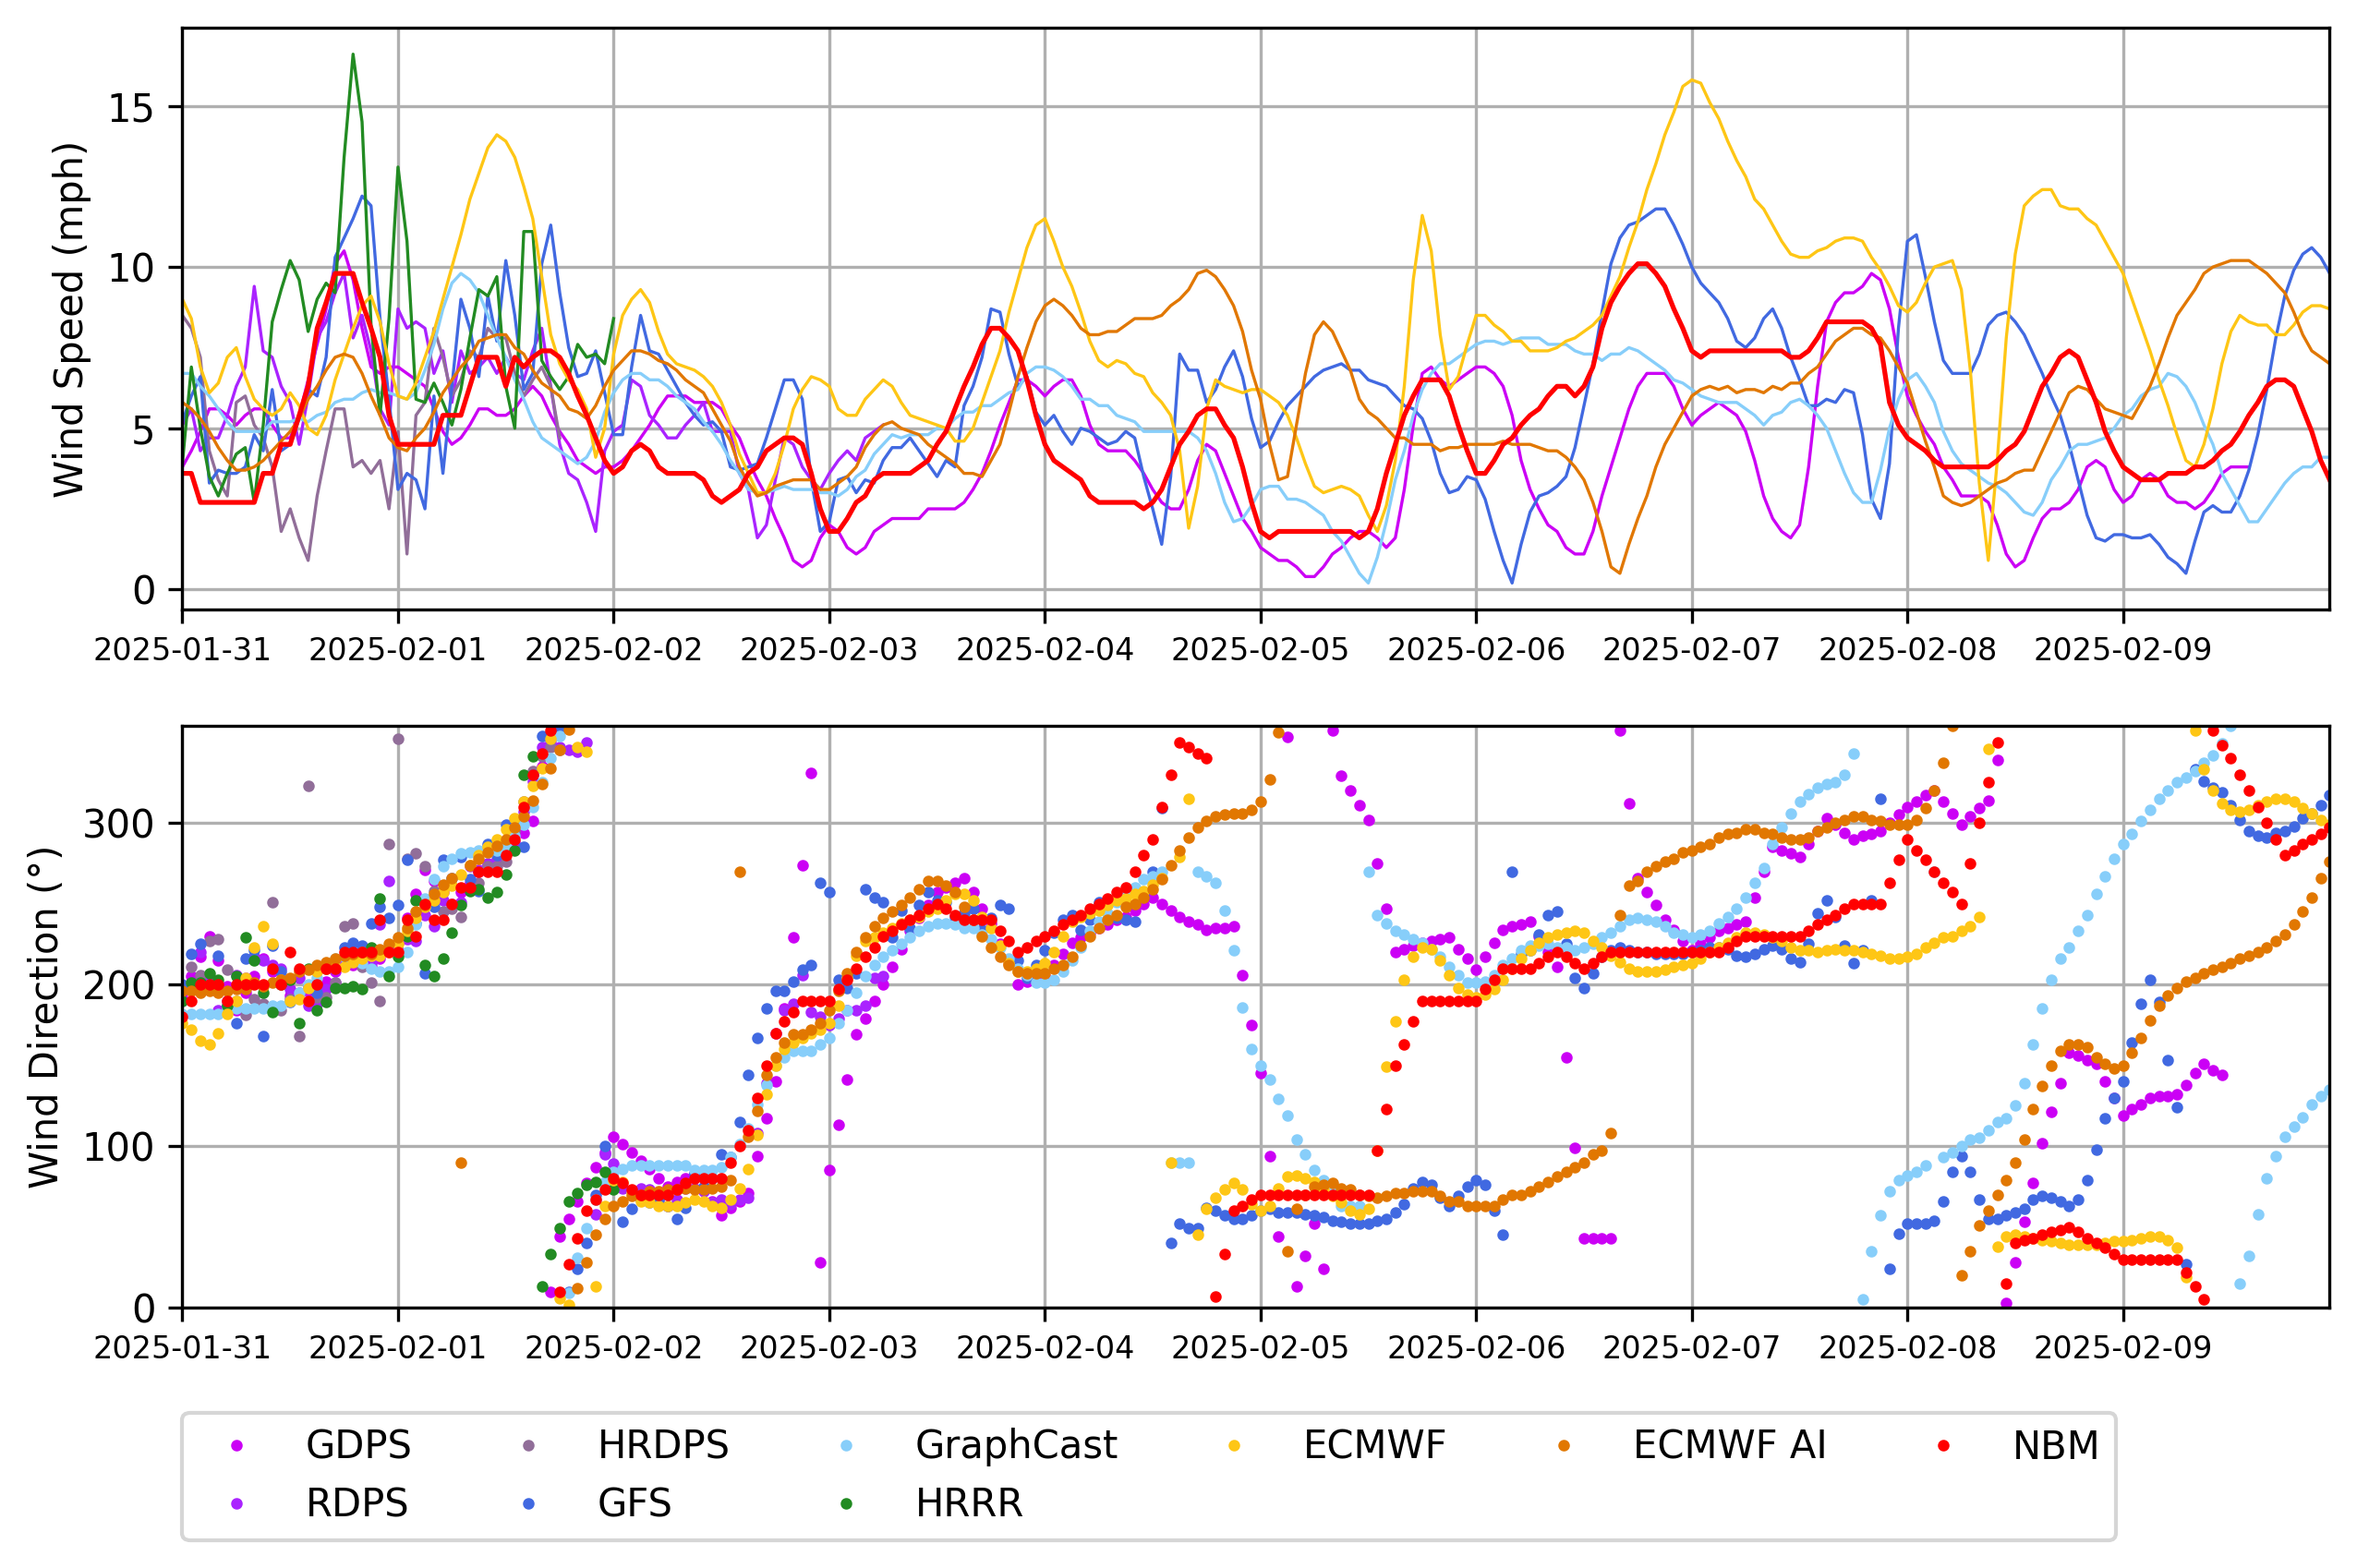

In [27]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(10,6))

ax1.plot(GDPSdataframe[timeName], GDPSdataframe[windSpeedName], color=GDPScolor, linewidth=linewidth)
ax1.plot(RDPSdataframe[timeName], RDPSdataframe[windSpeedName], color=RDPScolor, linewidth=linewidth)
ax1.plot(HRDPSdataframe[timeName], HRDPSdataframe[windSpeedName], color=HRDPScolor, linewidth=linewidth)
ax1.plot(GFSdataframe[timeName], GFSdataframe[windSpeedName], color=GFScolor, linewidth=linewidth)
ax1.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[windSpeedName], color=GFS_GCcolor, linewidth=linewidth)
ax1.plot(HRRRdataframe[timeName], HRRRdataframe[windSpeedName], color=HRRRcolor, linewidth=linewidth)
ax1.plot(ECMWFdataframe[timeName], ECMWFdataframe[windSpeedName], color=ECMWFcolor, linewidth=linewidth)
ax1.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[windSpeedName], color=ECMWF_AIcolor, linewidth=linewidth)
ax1.plot(NBMdataframe[timeName], NBMdataframe[windSpeedName], color=NBMcolor, linewidth=NBMlinewidth)

markerStyle = dict(marker='.', markersize=4, linewidth=0)
ax2.plot(GDPSdataframe[timeName], GDPSdataframe[windDirName], color=GDPScolor, **markerStyle, label="GDPS")
ax2.plot(RDPSdataframe[timeName], RDPSdataframe[windDirName], color=RDPScolor, **markerStyle, label="RDPS")
ax2.plot(HRDPSdataframe[timeName], HRDPSdataframe[windDirName], color=HRDPScolor, **markerStyle, label="HRDPS")
ax2.plot(GFSdataframe[timeName], GFSdataframe[windDirName], color=GFScolor, **markerStyle, label="GFS")
ax2.plot(GFS_GCdataframe[timeName], GFS_GCdataframe[windDirName], color=GFS_GCcolor, **markerStyle, label="GraphCast")
ax2.plot(HRRRdataframe[timeName], HRRRdataframe[windDirName], color=HRRRcolor, **markerStyle, label="HRRR")
ax2.plot(ECMWFdataframe[timeName], ECMWFdataframe[windDirName], color=ECMWFcolor, **markerStyle, label="ECMWF")
ax2.plot(ECMWF_AIdataframe[timeName], ECMWF_AIdataframe[windDirName], color=ECMWF_AIcolor, **markerStyle, label="ECMWF AI")
ax2.plot(NBMdataframe[timeName], NBMdataframe[windDirName], color=NBMcolor, **markerStyle, label="NBM")

ax1.grid(True)
ax2.grid(True)

ax1.set_ylabel("Wind Speed (mph)")
ax2.set_ylabel("Wind Direction (°)")

plt.setp(ax1, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]])
plt.setp(ax2, xlim=[NBMdataframe[timeName].iloc[0], NBMdataframe[timeName].iloc[-1]], ylim=[0, 360])

leg = ax2.legend(loc=(0, -0.4), ncol=6)